In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from arch import arch_model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

In [3]:
DATA_DIR = Path(".")

indices = {
    "S&P500": pd.read_csv(DATA_DIR / "SP500 (1).csv"),
    "NASDAQ100": pd.read_csv(DATA_DIR / "NASDAQ100.csv"),
    "DowJones": pd.read_csv(DATA_DIR / "DOW.csv"),
    "Russell2000": pd.read_csv(DATA_DIR / "RUSSELL2000.csv"),
}

In [6]:
for name, df in indices.items():

    # Rename first column to Date
    df = df.rename(columns={"Price": "Date"})

    # Remove the "Ticker" and "Date" rows
    df = df.iloc[2:].copy()

    # Convert date column
    df["Date"] = pd.to_datetime(df["Date"])

    # Convert all other columns to numeric
    for col in ["Close", "High", "Low", "Open", "Volume"]:
        df[col] = pd.to_numeric(df[col])

    # Sort and reset index
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Save the cleaned dataframe back
    indices[name] = df

print(indices["S&P500"].head())

        Date        Close         High          Low         Open      Volume
0 2022-01-03  4796.560059  4796.640137  4758.169922  4778.140137  3831020000
1 2022-01-04  4793.540039  4818.620117  4774.270020  4804.509766  4683170000
2 2022-01-05  4700.580078  4797.700195  4699.439941  4787.990234  4887960000
3 2022-01-06  4696.049805  4725.009766  4671.259766  4693.390137  4295280000
4 2022-01-07  4677.029785  4707.950195  4662.740234  4697.660156  4181510000


In [7]:
for name, df in indices.items():

    df["Return"] = np.log(df["Close"] / df["Close"].shift(1)) * 100

    df.dropna(inplace=True)

    df.reset_index(drop=True, inplace=True)

print(indices["S&P500"][["Date", "Close", "Return"]].head())

        Date        Close    Return
0 2022-01-04  4793.540039 -0.062982
1 2022-01-05  4700.580078 -1.958326
2 2022-01-06  4696.049805 -0.096423
3 2022-01-07  4677.029785 -0.405844
4 2022-01-10  4670.290039 -0.144207


In [8]:
# =============================================================================
# Cell 5: Fit GARCH(1,1) Models
# =============================================================================
# Purpose:
# Estimate a GARCH(1,1) model for each stock index. The model captures
# volatility clustering by allowing today's conditional variance to depend
# on both yesterday's squared return (ARCH effect) and yesterday's variance
# (GARCH effect).
#
# We fit a separate model to each index so that volatility dynamics are
# estimated independently for the S&P 500, Nasdaq 100, Dow Jones, and
# Russell 2000.
#
# Output:
# A dictionary called `garch_results` containing the fitted GARCH model
# for each index.
# =============================================================================

garch_results = {}

for name, df in indices.items():

    model = arch_model(
        df["Return"],
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal",
        rescale=False,
    )

    result = model.fit(disp="off")

    garch_results[name] = result

    print(f"{name}: converged")

S&P500: converged
NASDAQ100: converged
DowJones: converged
Russell2000: converged


In [9]:
# =============================================================================
# Cell 6: Compute Conditional Volatility from the Fitted GARCH Models
# =============================================================================
# Purpose:
# Extract the estimated conditional volatility (σ_t) from each fitted GARCH
# model and attach it to the corresponding dataframe. This serves as the
# baseline volatility measure used in the prediction models.
# =============================================================================

for name, df in indices.items():

    result = garch_results[name]

    df["GARCH_Vol"] = result.conditional_volatility

print(indices["S&P500"][["Date", "Return", "GARCH_Vol"]].head())

        Date    Return  GARCH_Vol
0 2022-01-04 -0.062982   1.218123
1 2022-01-05 -1.958326   1.153004
2 2022-01-06 -0.096423   1.265255
3 2022-01-07 -0.405844   1.196959
4 2022-01-10 -0.144207   1.142720


In [10]:
# =============================================================================
# Cell 7: Create Prediction Target
# =============================================================================
# Purpose:
# Shift the conditional volatility forward by one trading day so that today's
# information is used to predict tomorrow's volatility.
# =============================================================================

for name, df in indices.items():

    df["Volatility_tomorrow"] = df["GARCH_Vol"].shift(-1)

    df.dropna(inplace=True)

    df.reset_index(drop=True, inplace=True)

print(
    indices["S&P500"][
        ["Date", "GARCH_Vol", "Volatility_tomorrow"]
    ].head()
)

        Date  GARCH_Vol  Volatility_tomorrow
0 2022-01-04   1.218123             1.153004
1 2022-01-05   1.153004             1.265255
2 2022-01-06   1.265255             1.196959
3 2022-01-07   1.196959             1.142720
4 2022-01-10   1.142720             1.084797


In [11]:
# =============================================================================
# Cell 8: Load Daily Attention Signature Indices
# =============================================================================
# Purpose:
# Load the daily cluster indices produced from the SAX clustering pipeline.
# Each column represents the aggregate attention level of one cluster on a
# given day. These variables will be used as predictors alongside the GARCH
# baseline.
# =============================================================================

clusters = pd.read_csv("cluster_indices.csv")

clusters.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

clusters["Date"] = pd.to_datetime(clusters["Date"])

clusters.head()

,Date,cluster_1_equal_norm,cluster_1_stability_weighted_norm,cluster_1_core_equal_norm,cluster_2_equal_norm,cluster_2_stability_weighted_norm,cluster_2_core_equal_norm,cluster_3_equal_norm,cluster_3_stability_weighted_norm,cluster_3_core_equal_norm,...,cluster_3_core_equal_level,cluster_4_equal_level,cluster_4_stability_weighted_level,cluster_4_core_equal_level,cluster_5_equal_level,cluster_5_stability_weighted_level,cluster_5_core_equal_level,cluster_6_equal_level,cluster_6_stability_weighted_level,cluster_6_core_equal_level
0,2022-01-01,-3.299895,-3.259964,-2.386681,12.238595,13.649931,13.024344,2.388183,0.974157,-0.276705,...,47.146970,32.313743,44.452774,67.885493,26.742096,32.913557,35.318333,9.582751,6.196580,2.032727
1,2022-01-02,-2.609585,-2.327482,-1.295609,7.314126,8.425543,9.124356,2.219838,1.406756,0.088075,...,48.147960,30.570238,41.520261,61.543714,24.571724,30.132595,32.082500,10.513209,7.225069,1.988182
2,2022-01-03,-2.008699,-1.589626,-0.503573,4.038831,4.953720,6.477324,2.043002,1.679575,0.348449,...,48.766250,29.231646,39.262045,56.699079,22.912904,27.939816,29.399048,11.200411,8.001315,1.968745
3,2022-01-04,-1.552572,-1.045869,0.018195,2.318077,3.156885,5.129269,1.881675,1.813318,0.515686,...,49.001840,28.297969,37.678125,53.351589,21.765638,26.335219,27.267976,11.644356,8.525319,1.974416
4,2022-01-05,-1.162479,-0.665018,0.246218,2.021688,2.897315,5.075560,1.726382,1.792589,0.581435,...,48.854729,27.769206,36.768502,51.501243,21.129925,25.318805,25.689286,11.845044,8.797081,2.005195


In [12]:
# =============================================================================
# Cell 9: Merge Cluster Indices with Market Data
# =============================================================================
# Purpose:
# Join the daily attention signature indices to each stock index using the
# trading date. This creates one modelling dataset per index containing both
# financial variables and attention-based predictors.
# =============================================================================

for name in indices:

    indices[name] = indices[name].merge(
        clusters,
        on="Date",
        how="left"
    )

print(indices["S&P500"].shape)
indices["S&P500"].head()

(1103, 45)


,Date,Close,High,Low,Open,Volume,Return,GARCH_Vol,Volatility_tomorrow,cluster_1_equal_norm,...,cluster_3_core_equal_level,cluster_4_equal_level,cluster_4_stability_weighted_level,cluster_4_core_equal_level,cluster_5_equal_level,cluster_5_stability_weighted_level,cluster_5_core_equal_level,cluster_6_equal_level,cluster_6_stability_weighted_level,cluster_6_core_equal_level
0,2022-01-04,4793.540039,4818.620117,4774.270020,4804.509766,4683170000,-0.062982,1.218123,1.153004,-1.552572,...,49.001840,28.297969,37.678125,53.351589,21.765638,26.335219,27.267976,11.644356,8.525319,1.974416
1,2022-01-05,4700.580078,4797.700195,4699.439941,4787.990234,4887960000,-1.958326,1.153004,1.265255,-1.162479,...,48.854729,27.769206,36.768502,51.501243,21.129925,25.318805,25.689286,11.845044,8.797081,2.005195
2,2022-01-06,4696.049805,4725.009766,4671.259766,4693.390137,4295280000,-0.096423,1.265255,1.196959,-0.928435,...,48.260406,27.995226,37.164565,52.300543,21.388039,25.246650,24.713203,12.055722,9.095693,1.913420
3,2022-01-07,4677.029785,4707.950195,4662.740234,4697.660156,4181510000,-0.405844,1.196959,1.142720,-0.921482,...,47.082001,27.979314,37.221850,53.117159,21.442661,24.890075,23.377273,11.657676,8.776751,1.911688
4,2022-01-10,4670.290039,4673.020020,4582.240234,4655.339844,4511810000,-0.144207,1.142720,1.084797,-0.057456,...,46.693307,28.441488,37.259871,52.598876,22.011719,25.663787,24.987013,10.015540,7.133428,2.864502


In [13]:
# =============================================================================
# Cell 10: Select Cluster Predictors
# =============================================================================

cluster_cols = [
    c for c in clusters.columns
    if c.endswith("_equal_norm")
]

print(cluster_cols)

['cluster_1_equal_norm', 'cluster_1_core_equal_norm', 'cluster_2_equal_norm', 'cluster_2_core_equal_norm', 'cluster_3_equal_norm', 'cluster_3_core_equal_norm', 'cluster_4_equal_norm', 'cluster_4_core_equal_norm', 'cluster_5_equal_norm', 'cluster_5_core_equal_norm', 'cluster_6_equal_norm', 'cluster_6_core_equal_norm']


In [14]:
# =============================================================================
# Cell 11: Baseline vs Enhanced Prediction Models
# =============================================================================
# Purpose:
# Compare a baseline model using only GARCH volatility with an enhanced model
# that also incorporates the attention-signature cluster indices.
# =============================================================================

results = []

for name, df in indices.items():

    # Keep only rows with complete data
    model_df = df.dropna().copy()

    X_baseline = model_df[["GARCH_Vol"]]

    X_enhanced = model_df[["GARCH_Vol"] + cluster_cols]

    y = model_df["Volatility_tomorrow"]

    split = int(len(model_df) * 0.8)

    Xb_train = X_baseline.iloc[:split]
    Xb_test = X_baseline.iloc[split:]

    Xe_train = X_enhanced.iloc[:split]
    Xe_test = X_enhanced.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    baseline = LinearRegression()
    baseline.fit(Xb_train, y_train)

    enhanced = LinearRegression()
    enhanced.fit(Xe_train, y_train)

    pred_base = baseline.predict(Xb_test)
    pred_enh = enhanced.predict(Xe_test)

    rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
    rmse_enh = np.sqrt(mean_squared_error(y_test, pred_enh))

    mae_base = mean_absolute_error(y_test, pred_base)
    mae_enh = mean_absolute_error(y_test, pred_enh)

    oos_r2 = 1 - (
        np.sum((y_test - pred_enh) ** 2)
        /
        np.sum((y_test - pred_base) ** 2)
    )

    results.append({
        "Index": name,
        "Baseline RMSE": rmse_base,
        "Enhanced RMSE": rmse_enh,
        "Baseline MAE": mae_base,
        "Enhanced MAE": mae_enh,
        "OOS R²": oos_r2,
    })

In [15]:
# =============================================================================
# Cell 12: Results Summary
# =============================================================================

results = pd.DataFrame(results)

results = results.round(4)

results

,Index,Baseline RMSE,Enhanced RMSE,Baseline MAE,Enhanced MAE,OOS R²
0,S&P500,0.0589,0.0634,0.0382,0.0418,-0.1596
1,NASDAQ100,0.0669,0.0726,0.0476,0.0514,-0.1782
2,DowJones,0.0463,0.0490,0.0320,0.0324,-0.1209
3,Russell2000,0.0482,0.0547,0.0357,0.0373,-0.2842


In [17]:
# =============================================================================
# Evaluate each attention cluster individually
# =============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

results = []

for index_name, df in indices.items():

    df = df.dropna().copy()

    y = df["Volatility_tomorrow"]

    split = int(0.8 * len(df))

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # -----------------------------
    # Baseline model (GARCH only)
    # -----------------------------

    X_base = df[["GARCH_Vol"]]

    Xb_train = X_base.iloc[:split]
    Xb_test = X_base.iloc[split:]

    baseline = LinearRegression()
    baseline.fit(Xb_train, y_train)

    pred_base = baseline.predict(Xb_test)

    rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
    mae_base = mean_absolute_error(y_test, pred_base)

    # -----------------------------
    # Test every cluster separately
    # -----------------------------

    for cluster in cluster_cols:

        X = df[["GARCH_Vol", cluster]]

        X_train = X.iloc[:split]
        X_test = X.iloc[split:]

        model = LinearRegression()

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)

        oos_r2 = 1 - (
            np.sum((y_test - pred) ** 2)
            /
            np.sum((y_test - pred_base) ** 2)
        )

        results.append({

            "Index": index_name,
            "Cluster": cluster,

            "OOS_R2": oos_r2,

            "RMSE_Improvement": rmse_base - rmse,

            "MAE_Improvement": mae_base - mae

        })

results = pd.DataFrame(results)

results.head()

,Index,Cluster,OOS_R2,RMSE_Improvement,MAE_Improvement
0,S&P500,cluster_1_equal_norm,0.014508,0.000429,0.000802
1,S&P500,cluster_1_core_equal_norm,-0.008594,-0.000252,0.000071
2,S&P500,cluster_2_equal_norm,-0.001561,-0.000046,0.000285
3,S&P500,cluster_2_core_equal_norm,0.002752,0.000081,0.000348
4,S&P500,cluster_3_equal_norm,-0.051258,-0.001490,0.000487


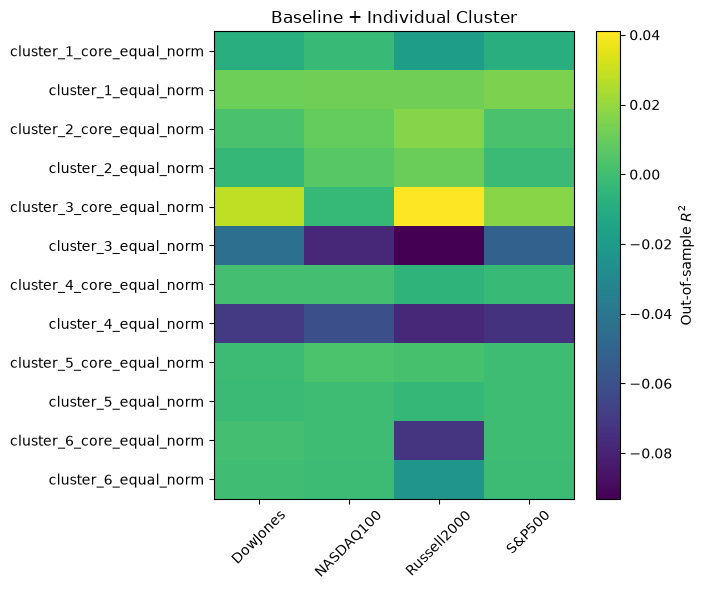

In [18]:
import matplotlib.pyplot as plt

heat = results.pivot(
    index="Cluster",
    columns="Index",
    values="OOS_R2"
)

plt.figure(figsize=(7,6))
plt.imshow(heat, aspect="auto")

plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)

plt.colorbar(label="Out-of-sample $R^2$")

plt.title("Baseline + Individual Cluster")
plt.tight_layout()
plt.show()

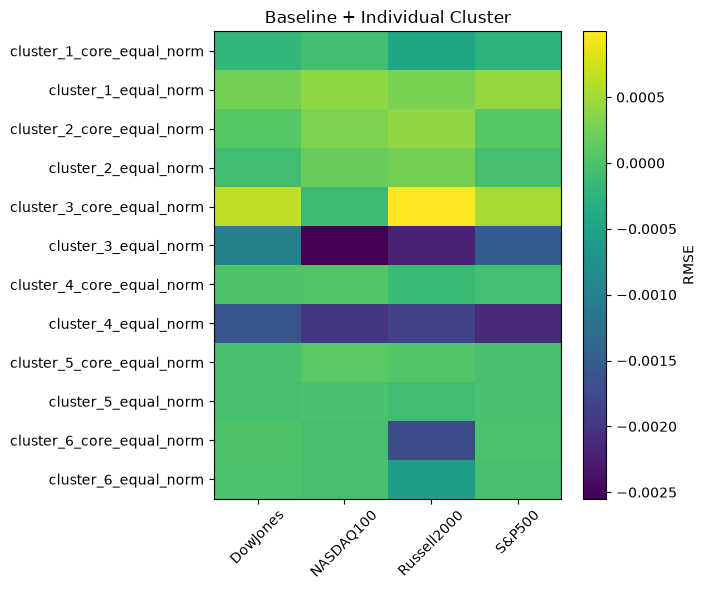

In [19]:
import matplotlib.pyplot as plt

heat = results.pivot(
    index="Cluster",
    columns="Index",
    values="RMSE_Improvement"
)

plt.figure(figsize=(7,6))
plt.imshow(heat, aspect="auto")

plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)

plt.colorbar(label="RMSE")

plt.title("Baseline + Individual Cluster")
plt.tight_layout()
plt.show()

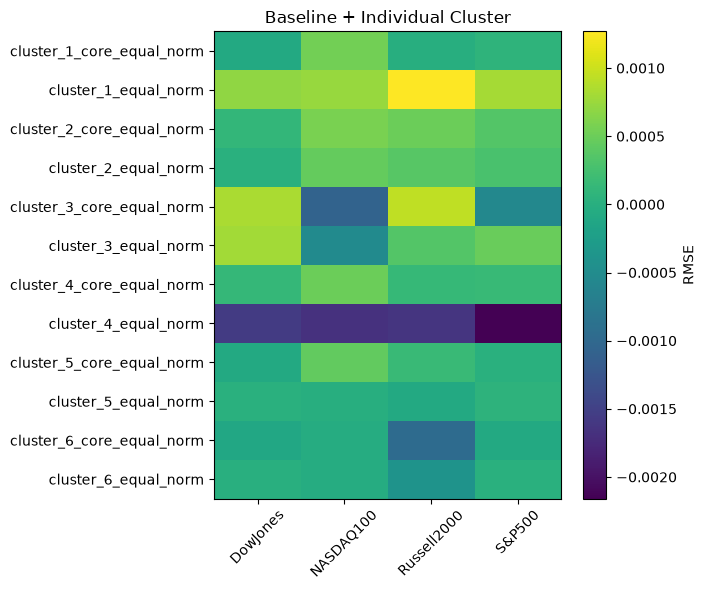

In [20]:
import matplotlib.pyplot as plt

heat = results.pivot(
    index="Cluster",
    columns="Index",
    values="MAE_Improvement"
)

plt.figure(figsize=(7,6))
plt.imshow(heat, aspect="auto")

plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)

plt.colorbar(label="RMSE")

plt.title("Baseline + Individual Cluster")
plt.tight_layout()
plt.show()